# Factors Influencing Electric Vehicle (EV) Adoption

## Data Analytics Project

### Author
Devika D

### Objective
The objective of this project is to identify the key factors influencing Electric Vehicle (EV) adoption and provide business recommendations using data analytics techniques.

### Tools Used
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Jupyter Notebook

In [ ]:
pip install pandas

# Dataset Loading and Understanding

The dataset is imported into Python for analysis. This section loads the dataset and prepares it for exploration and cleaning.

### Dataset Description

The dataset contains consumer demographic, behavioral, economic, and environmental factors that may influence EV adoption likelihood.

In [69]:
df=pd.read_csv("global_ev_adoption_behavior_2026.csv")
print(df.shape)
print(df.columns)
print(df.info())


(50000, 23)
Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income      

# EV Adoption Distribution Analysis

This section examines how respondents are distributed across different EV adoption categories.

### Business Question

What proportion of consumers exhibit High, Medium, or Low EV adoption likelihood?

In [70]:
print(df["ev_adoption_likelihood"].value_counts())
print(df["education_level"].value_counts())
print(df["city_type"].value_counts())
print(df["current_vehicle_type"].value_counts())

ev_adoption_likelihood
High      29670
Medium    12078
Low        8252
Name: count, dtype: int64
education_level
Bachelor       22350
High School    12401
Master         12244
PhD             2505
Name: count, dtype: int64
city_type
Urban       22645
Suburban    17348
Rural       10007
Name: count, dtype: int64
current_vehicle_type
Sedan        17512
SUV          14933
Hatchback    12561
Truck         4994
Name: count, dtype: int64


### Observation
The High Adoption category contains the largest number of respondents.
### Business Insight
A significant portion of consumers demonstrate strong interest in electric vehicles, indicating positive market potential for EV adoption.

# Education Level vs EV Adoption

This analysis investigates whether educational background influences EV adoption likelihood.

### Business Question

Do consumers with different education levels exhibit different EV adoption behavior?

In [71]:
print(pd.crosstab(df["education_level"],df["ev_adoption_likelihood"],
normalize="index"))


ev_adoption_likelihood      High       Low    Medium
education_level                                     
Bachelor                0.596152  0.164116  0.239732
High School             0.589791  0.165632  0.244577
Master                  0.593352  0.166367  0.240281
PhD                     0.591218  0.166068  0.242715


### Observation

The adoption distribution appears relatively similar across education categories.

### Business Insight

Education alone does not appear to be a major differentiating factor influencing EV adoption in this dataset.

# Income Analysis

This section examines the relationship between annual income and EV adoption likelihood.

### Business Question

Does income influence a consumer's willingness to adopt electric vehicles?

In [72]:
print(df.groupby("ev_adoption_likelihood")["annual_income"].mean())

ev_adoption_likelihood
High      52219.834007
Low       29402.017693
Medium    35072.490810
Name: annual_income, dtype: float64


### Observation

Consumers in the High Adoption category have significantly higher average income than Medium and Low Adoption groups.

### Business Insight

Income is a strong driver of EV adoption, as higher-income individuals are more capable of purchasing electric vehicles.

# Environmental Awareness Analysis

Environmental consciousness is expected to influence EV adoption behavior.

### Business Question

Are environmentally aware consumers more likely to adopt EVs?

In [73]:
df.groupby(
    "ev_adoption_likelihood"
)["fuel_expense_per_month"].mean()

ev_adoption_likelihood
High      295.425912
Low       294.428672
Medium    295.046216
Name: fuel_expense_per_month, dtype: float64

In [74]:
df.groupby(
    "ev_adoption_likelihood"
)["environmental_awareness_score"].mean()

ev_adoption_likelihood
High      7.862632
Low       4.467523
Medium    5.915085
Name: environmental_awareness_score, dtype: float64

### Observation

Environmental awareness increases as EV adoption likelihood increases.

### Business Insight

Consumers who are more environmentally conscious are more likely to adopt electric vehicles.

# Range Anxiety Analysis

Range anxiety refers to the concern that an EV may not have sufficient battery capacity to complete a journey.

### Business Question

Does range anxiety affect EV adoption?

In [75]:
print(df.groupby("ev_adoption_likelihood")["range_anxiety_score"].mean())

ev_adoption_likelihood
High      4.136363
Low       7.757477
Medium    6.430013
Name: range_anxiety_score, dtype: float64


### Observation

Consumers with lower range anxiety exhibit higher EV adoption likelihood.

### Business Insight

Range anxiety remains one of the strongest barriers preventing EV adoption.

# Home Charging Availability

This analysis investigates the impact of home charging infrastructure on EV adoption.

### Business Question

Does access to home charging increase EV adoption likelihood?

In [76]:
print(df.groupby("ev_adoption_likelihood")["home_charging_available"].mean()*100)

ev_adoption_likelihood
High      68.392315
Low       56.434804
Medium    62.419275
Name: home_charging_available, dtype: float64


### Observation

Home charging availability is higher among consumers with High EV adoption likelihood.

### Business Insight

Home charging infrastructure positively influences EV adoption.

# Visual Analysis

The following visualizations provide graphical insights into EV adoption behavior and consumer characteristics.

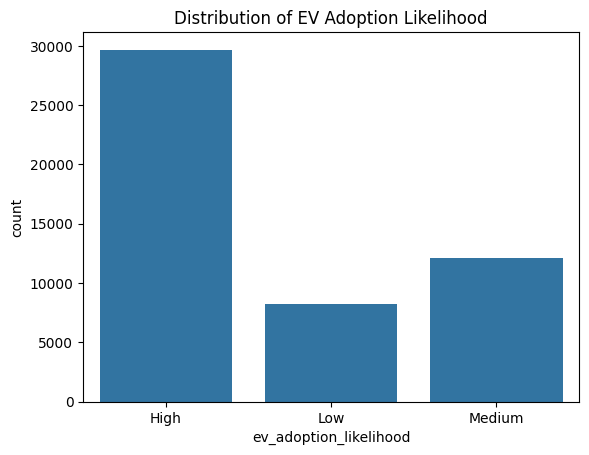

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df,x="ev_adoption_likelihood")
plt.title("Distribution of EV Adoption Likelihood")
plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

### Objective

Identify factors that are positively or negatively associated with EV adoption behavior.

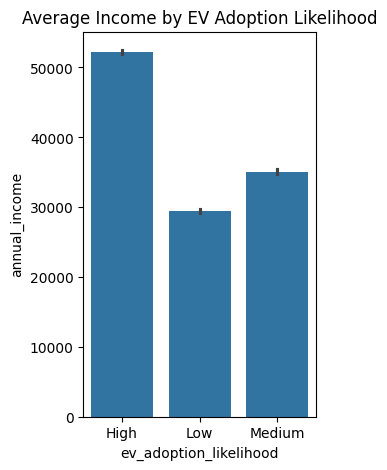

In [78]:
plt.figure(figsize=(3,5))
sns.barplot(data=df,x="ev_adoption_likelihood",y="annual_income")
plt.title("Average Income by EV Adoption Likelihood")
plt.show()

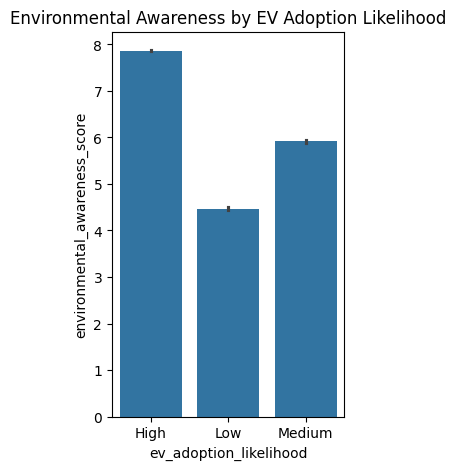

In [79]:
plt.figure(figsize=(3,5))
sns.barplot(data=df,x="ev_adoption_likelihood",y="environmental_awareness_score")
plt.title("Environmental Awareness by EV Adoption Likelihood")
plt.show()

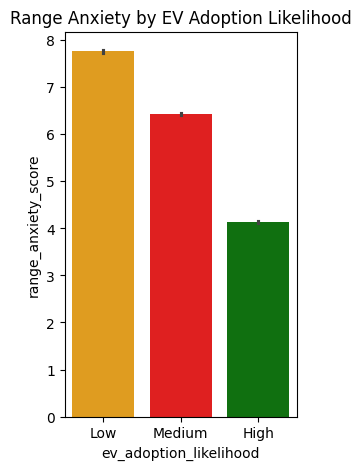

In [80]:
plt.figure(figsize=(3,5))

sns.barplot(
    data=df,
    x="ev_adoption_likelihood",
    y="range_anxiety_score",
    order=["Low","Medium","High"],
    hue="ev_adoption_likelihood",palette=["green","orange","red"],legend=False
)

plt.title("Range Anxiety by EV Adoption Likelihood")

plt.show()

In [81]:
corr=df.corr(numeric_only=True)
corr

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
age,1.000000,-0.004244,-0.005042,-0.004831,-0.001774,-0.004150,-0.005380,-0.000833,0.000179,-0.000437,-0.005495,0.002033,-0.000675,0.001458,-0.000389,-0.005003,-0.000335,-0.003461,-0.002225
annual_income,-0.004244,1.000000,0.000434,-0.000126,0.001579,-0.000225,0.000077,-0.003564,-0.003209,0.004607,0.316546,0.003436,0.448863,-0.369841,0.001748,0.382863,-0.006043,0.002640,0.003613
daily_commute_km,-0.005042,0.000434,1.000000,0.944852,-0.006027,0.951539,-0.003056,0.000991,0.008939,0.000073,0.004628,-0.000623,0.005281,0.000566,-0.003723,0.000477,0.001189,0.884948,0.676037
weekly_travel_distance_km,-0.004831,-0.000126,0.944852,1.000000,-0.003314,0.898885,-0.001344,0.000564,0.008867,0.001769,0.005971,-0.000640,0.005322,-0.000685,-0.000820,0.001102,-0.001768,0.936115,0.715476
vehicle_age_years,-0.001774,0.001579,-0.006027,-0.003314,1.000000,-0.008997,-0.011031,0.006891,-0.000083,0.007535,-0.006825,-0.000440,-0.003061,-0.001909,-0.006717,-0.004620,-0.000001,-0.003190,-0.000322
fuel_expense_per_month,-0.004150,-0.000225,0.951539,0.898885,-0.008997,1.000000,-0.003575,-0.002154,0.007795,0.001788,0.003766,0.002103,0.003635,0.002218,-0.004115,-0.000048,0.002505,0.842182,0.644071
charging_station_accessibility,-0.005380,0.000077,-0.003056,-0.001344,-0.011031,-0.003575,1.000000,-0.293203,-0.001493,-0.005064,0.004147,-0.003768,0.003774,-0.000558,0.001203,0.006731,-0.005144,-0.000136,-0.002397
nearest_charging_station_km,-0.000833,-0.003564,0.000991,0.000564,0.006891,-0.002154,-0.293203,1.000000,-0.001072,0.002761,-0.003333,-0.003325,-0.001339,0.002467,-0.004109,-0.003539,-0.009308,0.000629,0.000983
home_charging_available,0.000179,-0.003209,0.008939,0.008867,-0.000083,0.007795,-0.001493,-0.001072,1.000000,0.008744,-0.006349,0.001630,-0.003705,0.006191,-0.000234,-0.007812,0.012187,0.007036,0.010099
electricity_cost_per_kwh,-0.000437,0.004607,0.000073,0.001769,0.007535,0.001788,-0.005064,0.002761,0.008744,1.000000,-0.002969,0.006316,0.005301,-0.001965,0.010848,0.005227,0.003606,0.003133,0.583916


In [82]:
corr["annual_income"].sort_values(ascending=False)

annual_income                     1.000000
technology_affinity_score         0.448863
ev_knowledge_score                0.382863
environmental_awareness_score     0.316546
electricity_cost_per_kwh          0.004607
monthly_charging_cost             0.003613
government_incentive_awareness    0.003436
monthly_energy_consumption_kwh    0.002640
battery_replacement_concern       0.001748
vehicle_age_years                 0.001579
daily_commute_km                  0.000434
charging_station_accessibility    0.000077
weekly_travel_distance_km        -0.000126
fuel_expense_per_month           -0.000225
home_charging_available          -0.003209
nearest_charging_station_km      -0.003564
age                              -0.004244
previous_ev_experience           -0.006043
range_anxiety_score              -0.369841
Name: annual_income, dtype: float64

In [83]:
corr["annual_income"].sort_values(ascending=False)

annual_income                     1.000000
technology_affinity_score         0.448863
ev_knowledge_score                0.382863
environmental_awareness_score     0.316546
electricity_cost_per_kwh          0.004607
monthly_charging_cost             0.003613
government_incentive_awareness    0.003436
monthly_energy_consumption_kwh    0.002640
battery_replacement_concern       0.001748
vehicle_age_years                 0.001579
daily_commute_km                  0.000434
charging_station_accessibility    0.000077
weekly_travel_distance_km        -0.000126
fuel_expense_per_month           -0.000225
home_charging_available          -0.003209
nearest_charging_station_km      -0.003564
age                              -0.004244
previous_ev_experience           -0.006043
range_anxiety_score              -0.369841
Name: annual_income, dtype: float64

### Heatmap Interpretation

The heatmap highlights strong positive and negative relationships between variables.

### Key Insight

Environmental awareness, EV knowledge, and technology affinity are strongly related, while range anxiety shows negative relationships with several adoption-related factors.

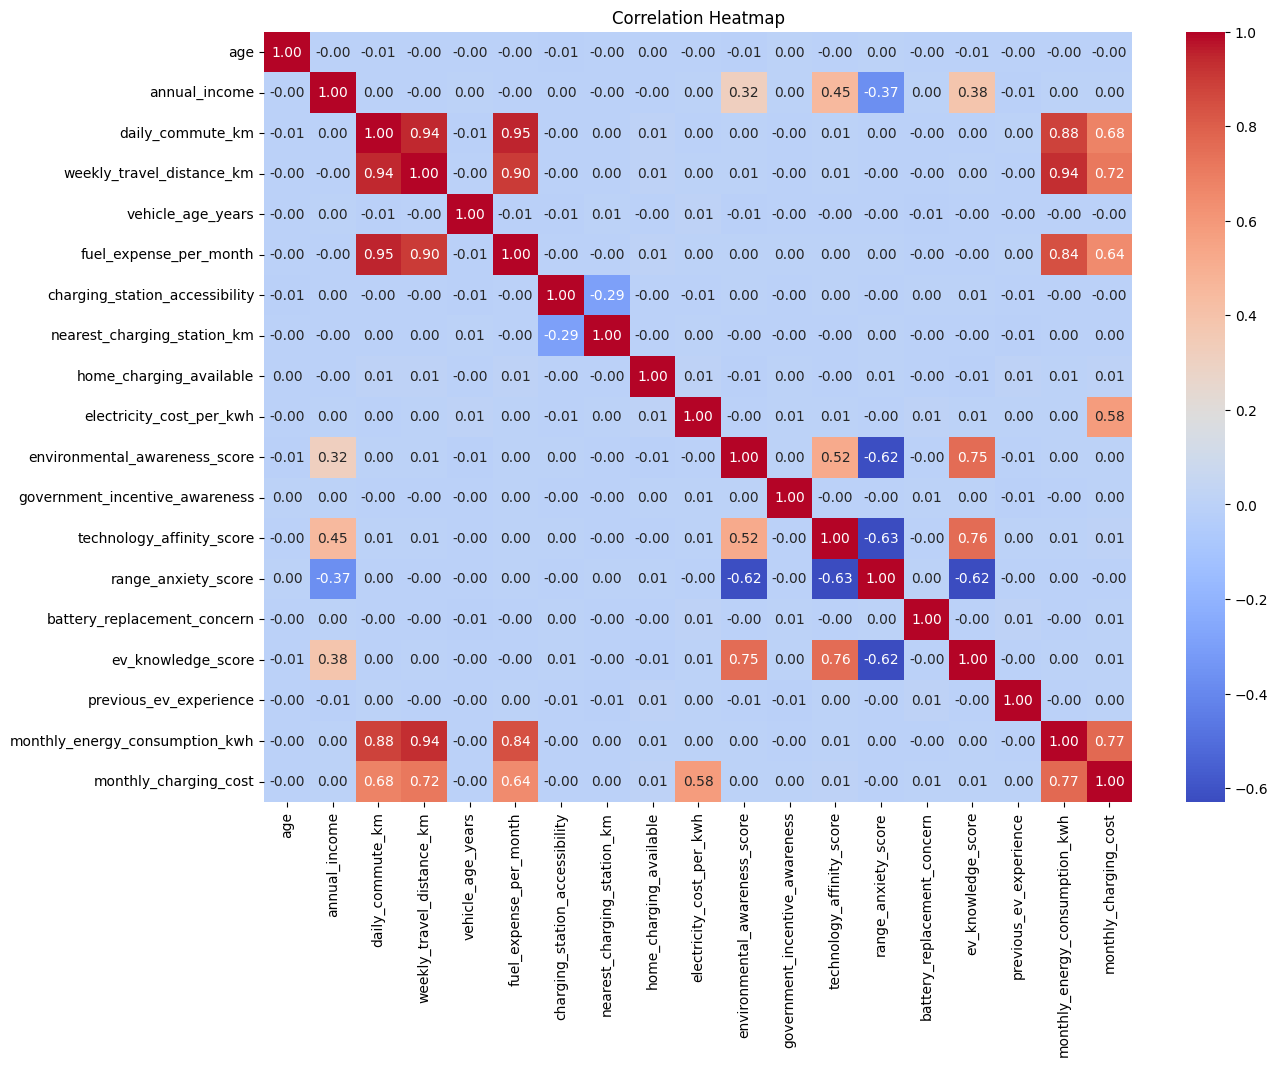

In [84]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Distribution Analysis

Distribution analysis helps understand the spread, concentration, and skewness of numerical variables.

The following histogram examines annual income distribution.


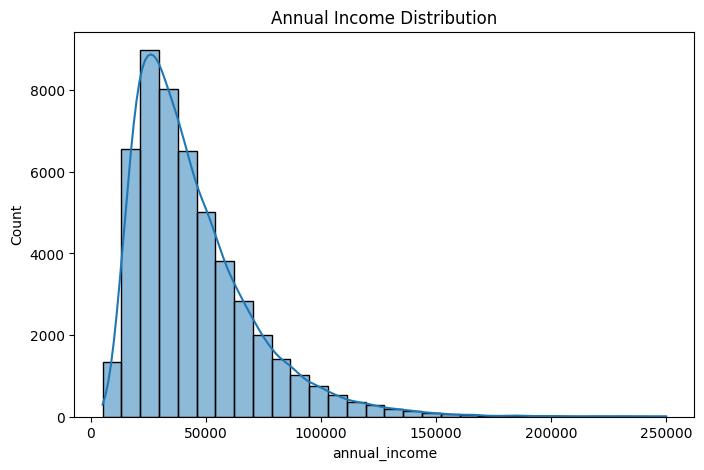

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["annual_income"],
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

### Observation

The income distribution is positively skewed and contains several upper-end outliers.

### Business Insight

A small number of high-income consumers significantly increase the upper tail of the distribution.

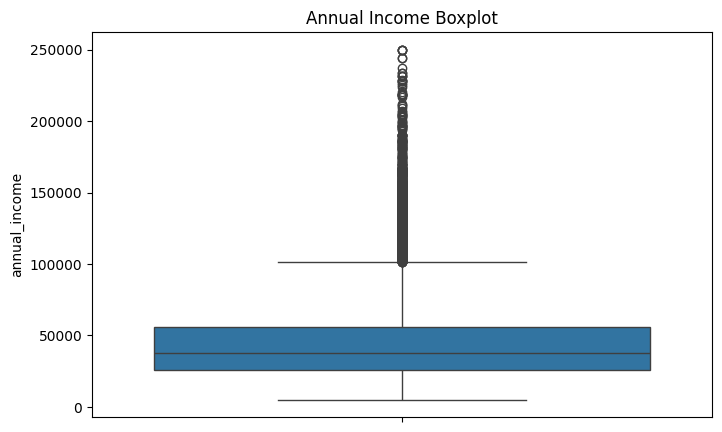

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["annual_income"]
)

plt.title("Annual Income Boxplot")

plt.show()

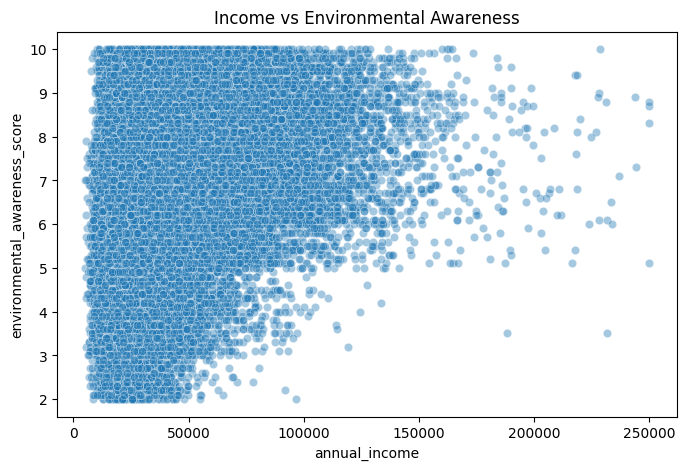

In [87]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="environmental_awareness_score",
    alpha=0.4
)

plt.title("Income vs Environmental Awareness")

plt.show()

<Axes: xlabel='annual_income', ylabel='environmental_awareness_score'>

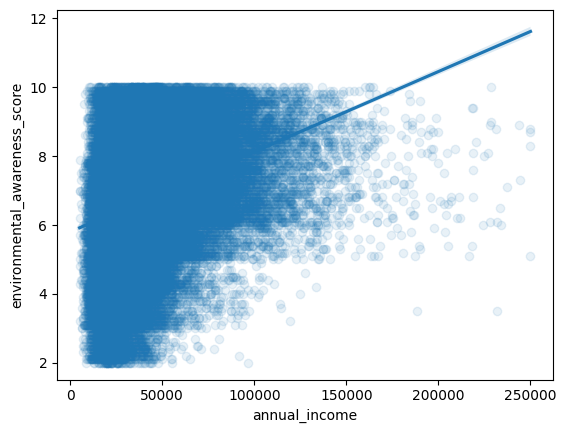

In [88]:
sns.regplot(
    data=df,
    x="annual_income",
    y="environmental_awareness_score",
    scatter_kws={"alpha":0.1}
)

# Relationship Analysis

Scatter plots and regression plots help visualize relationships between numerical variables.

The following chart examines the relationship between environmental awareness and EV knowledge.

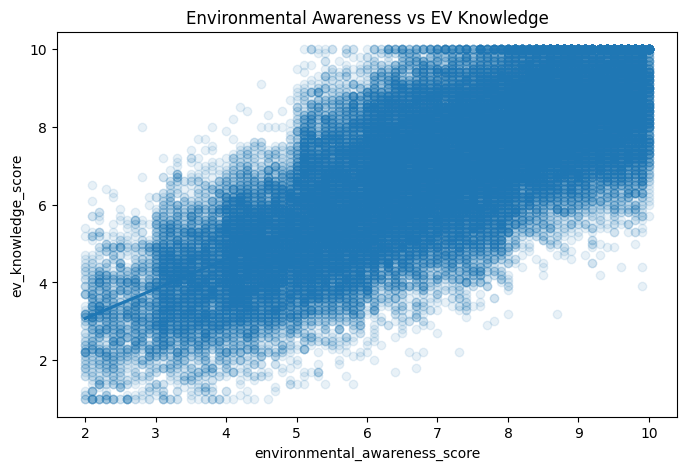

In [89]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="environmental_awareness_score",
    y="ev_knowledge_score",
    scatter_kws={"alpha":0.1}
)

plt.title("Environmental Awareness vs EV Knowledge")

plt.show()

# Advanced Aggregation Analysis

Pivot tables summarize information across multiple dimensions and help identify patterns in the data.

In [90]:
pd.pivot_table(
    df,
    values="annual_income",
    index="city_type",
    columns="ev_adoption_likelihood",
    aggfunc="mean"
)

ev_adoption_likelihood,High,Low,Medium
city_type,,,
Rural,52560.881860,29806.135464,36666.116817
Suburban,53150.822870,29314.990928,36887.021705
Urban,51494.461183,29227.734986,32665.516014


In [91]:
df.groupby("ev_adoption_likelihood")["annual_income"].agg(
    ["mean", "min", "max", "count"]
)

,mean,min,max,count
ev_adoption_likelihood,,,,
High,52219.834007,5274.0,250000.0,29670
Low,29402.017693,5357.0,188434.0,8252
Medium,35072.490810,5104.0,231595.0,12078


# Data Cleaning

Data quality assessment is performed to identify missing values and duplicate records.

Missing values are treated using appropriate imputation techniques.

In [92]:
df.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

In [93]:
df["education_level"].fillna(
    df["education_level"].mode()[0],
    inplace=True
)

C:\Users\Telan\AppData\Local\Temp\ipykernel_6024\867502916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education_level"].fillna(


In [94]:
df["charging_station_accessibility"] = df[
    "charging_station_accessibility"
].fillna(
    df["charging_station_accessibility"].median()
)

In [95]:
df["ev_knowledge_score"] = df[
    "ev_knowledge_score"
].fillna(
    df["ev_knowledge_score"].median()
)

In [96]:
df.isnull().sum()

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64

In [97]:
df.duplicated().sum()

np.int64(0)

### Data Cleaning Summary

- Missing values identified and treated
- No duplicate records found
- Dataset prepared for analysis

The cleaned dataset is now suitable for further analysis and dashboard development.

# Executive KPI Summary

The following metrics provide a high-level overview of the dataset and EV adoption landscape.

In [98]:
summary = {
    "Total Respondents": len(df),
    "High Adoption": (df["ev_adoption_likelihood"]=="High").sum(),
    "Medium Adoption": (df["ev_adoption_likelihood"]=="Medium").sum(),
    "Low Adoption": (df["ev_adoption_likelihood"]=="Low").sum(),
    "Average Income": round(df["annual_income"].mean(),2),
    "Average Awareness": round(df["environmental_awareness_score"].mean(),2),
    "Average Range Anxiety": round(df["range_anxiety_score"].mean(),2)
}

summary

{'Total Respondents': 50000,
 'High Adoption': np.int64(29670),
 'Medium Adoption': np.int64(12078),
 'Low Adoption': np.int64(8252),
 'Average Income': np.float64(44311.87),
 'Average Awareness': np.float64(6.83),
 'Average Range Anxiety': np.float64(5.29)}

In [99]:
high_pct = round((29670/50000)*100,2)
medium_pct = round((12078/50000)*100,2)
low_pct = round((8252/50000)*100,2)

print(high_pct, medium_pct, low_pct)

59.34 24.16 16.5


# Conclusion

This analysis identified several important factors influencing EV adoption.

## Key Findings

1. Income positively influences EV adoption.
2. Environmental awareness encourages EV adoption.
3. Home charging availability improves adoption likelihood.
4. Range anxiety remains a major barrier.
5. EV knowledge and technology affinity support adoption behavior.

## Recommendations

- Expand charging infrastructure.
- Promote EV awareness programs.
- Encourage home charging installation.
- Provide incentives for middle-income consumers.

## Future Work

- Power BI Dashboard Development
- SQL-Based Analytics
- Machine Learning Prediction Model
- EV Adoption Recommendation System

In [100]:
df.to_csv("ev_cleaned.csv", index=False)